# 📧 Email Spam Detection with Machine Learning
### OIBSIP Internship – Task 4
**Author:** Youssef Hatem Mohamed Bahig  
**Program:** AICTE Oasis Infobyte Internship  

---

## 📌 Objective
Build a machine learning model that learns from SMS/email text messages and classifies them as:
- ✅ **Ham** (Legitimate message)
- 🚫 **Spam** (Junk / unwanted message)

---

## Step 1 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

import warnings
warnings.filterwarnings('ignore')


print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## Step 2 — Load the Dataset

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')

# Keep only relevant columns and rename
df = df[['v1', 'v2']].copy()
df.rename(columns={'v1': 'label', 'v2': 'message'}, inplace=True)

print('✅ Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head(10)

✅ Dataset loaded successfully!
Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


## Step 3 — Exploratory Data Analysis (EDA)

In [3]:
# Dataset Info
print('📋 Dataset Info:')
df.info()

📋 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [4]:
# Basic Statistics
print('📈 Statistical Summary:')
print(df['label'].value_counts())

print('\n❓ Missing Values:')
print(df.isnull().sum())

📈 Statistical Summary:
label
ham     4825
spam     747
Name: count, dtype: int64

❓ Missing Values:
label      0
message    0
dtype: int64


In [5]:
# Message length feature
df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

print('📊 Message Length Statistics by Label:')
df.groupby('label')[['message_length', 'word_count']].describe()

📊 Message Length Statistics by Label:


message_length                                                           \
               count        mean        std   min    25%    50%    75%    max   
label                                                                           
ham           4825.0   71.023627  58.016023   2.0   33.0   52.0   92.0  910.0   
spam           747.0  138.866131  29.183082  13.0  132.5  149.0  157.0  224.0   

      word_count                                                      
           count       mean        std  min   25%   50%   75%    max  
label                                                                 
ham       4825.0  14.200622  11.424511  1.0   7.0  11.0  19.0  171.0  
spam       747.0  23.851406   5.811898  2.0  22.0  25.0  28.0   35.0

## Step 4 — Visualizations

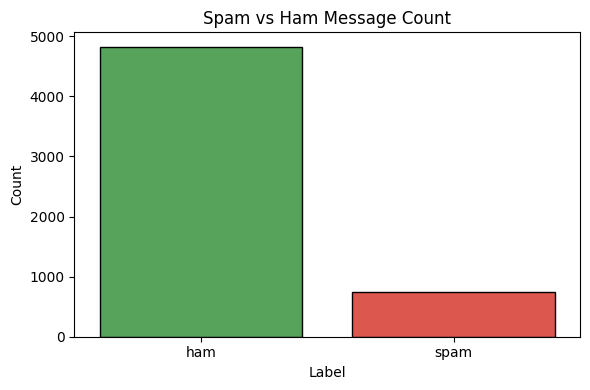

In [6]:
# 4a. Spam vs Ham Count Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette={'ham': '#4CAF50', 'spam': '#F44336'}, edgecolor='black')
plt.title('Spam vs Ham Message Count')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

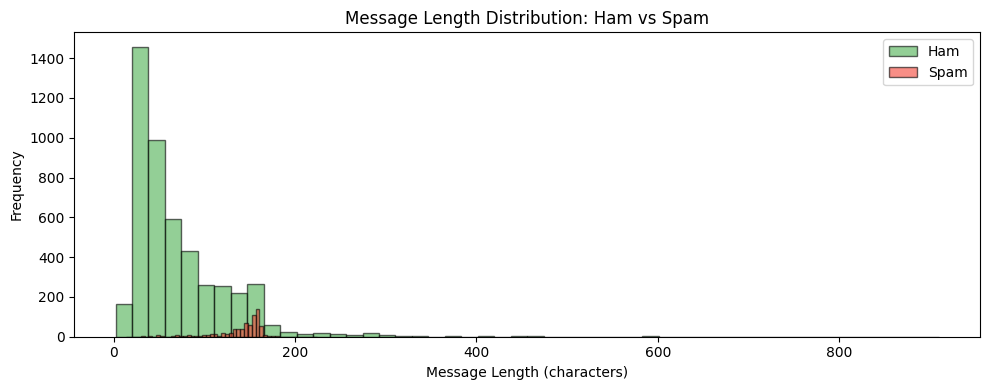

In [7]:
# 4b. Message Length Distribution
plt.figure(figsize=(10, 4))
for label, color in [('ham', '#4CAF50'), ('spam', '#F44336')]:
    subset = df[df['label'] == label]['message_length']
    plt.hist(subset, bins=50, alpha=0.6, color=color, label=label.capitalize(), edgecolor='black')
plt.title('Message Length Distribution: Ham vs Spam')
plt.xlabel('Message Length (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

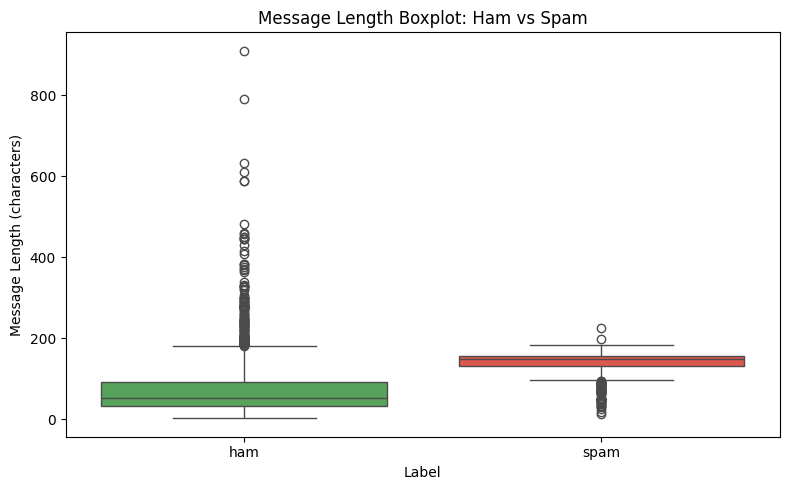

In [8]:
# 4c. Boxplot of message length by label
plt.figure(figsize=(8, 5))
sns.boxplot(x='label', y='message_length', data=df,
            palette={'ham': '#4CAF50', 'spam': '#F44336'})
plt.title('Message Length Boxplot: Ham vs Spam')
plt.xlabel('Label')
plt.ylabel('Message Length (characters)')
plt.tight_layout()
plt.show()

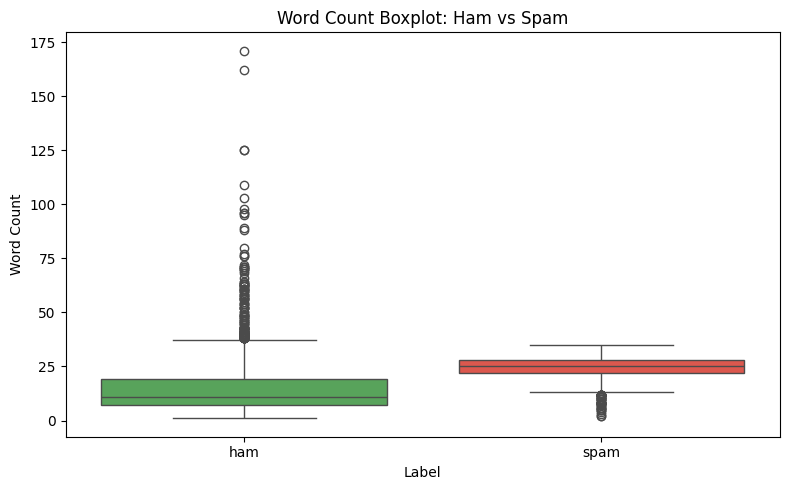

In [9]:
# 4d. Word count comparison
plt.figure(figsize=(8, 5))
sns.boxplot(x='label', y='word_count', data=df,
            palette={'ham': '#4CAF50', 'spam': '#F44336'})
plt.title('Word Count Boxplot: Ham vs Spam')
plt.xlabel('Label')
plt.ylabel('Word Count')
plt.tight_layout()
plt.show()

## Step 5 — Preprocessing

In [10]:
# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)          # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = text.strip()
    return text

df['cleaned_message'] = df['message'].apply(clean_text)

# Label Encoding
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])   # ham=0, spam=1

print('🏷️ Label Encoding:')
for i, cls in enumerate(le.classes_):
    print(f'   {cls} → {i}')

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X = tfidf.fit_transform(df['cleaned_message'])
y = df['label_encoded'].values

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\n📦 Training samples : {X_train.shape[0]}')
print(f'📦 Testing  samples : {X_test.shape[0]}')
print(f'📐 Vocabulary size  : {X_train.shape[1]}')

🏷️ Label Encoding:
   ham → 0
   spam → 1

📦 Training samples : 4457
📦 Testing  samples : 1115
📐 Vocabulary size  : 5000


## Step 6 — Train & Evaluate Models

In [11]:
models = {
    'Logistic Regression'     : LogisticRegression(max_iter=1000),
    'Decision Tree'           : DecisionTreeClassifier(random_state=42),
    'Random Forest'           : RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes'             : MultinomialNB(),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds    = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    results[name] = accuracy

    print('=' * 55)
    print(f'🤖 {name}')
    print(f'   Accuracy : {accuracy * 100:.2f}%')
    print(classification_report(y_test, preds, target_names=le.classes_))

🤖 Logistic Regression
   Accuracy : 95.87%
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       0.99      0.70      0.82       149

    accuracy                           0.96      1115
   macro avg       0.97      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115

🤖 Decision Tree
   Accuracy : 95.70%
              precision    recall  f1-score   support

         ham       0.97      0.98      0.98       966
        spam       0.87      0.79      0.83       149

    accuracy                           0.96      1115
   macro avg       0.92      0.89      0.90      1115
weighted avg       0.96      0.96      0.96      1115

🤖 Random Forest
   Accuracy : 97.40%
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       0.98      0.82      0.89       149

    accuracy                           0.97      1115
   macro av

## Step 7 — Compare Model Accuracies

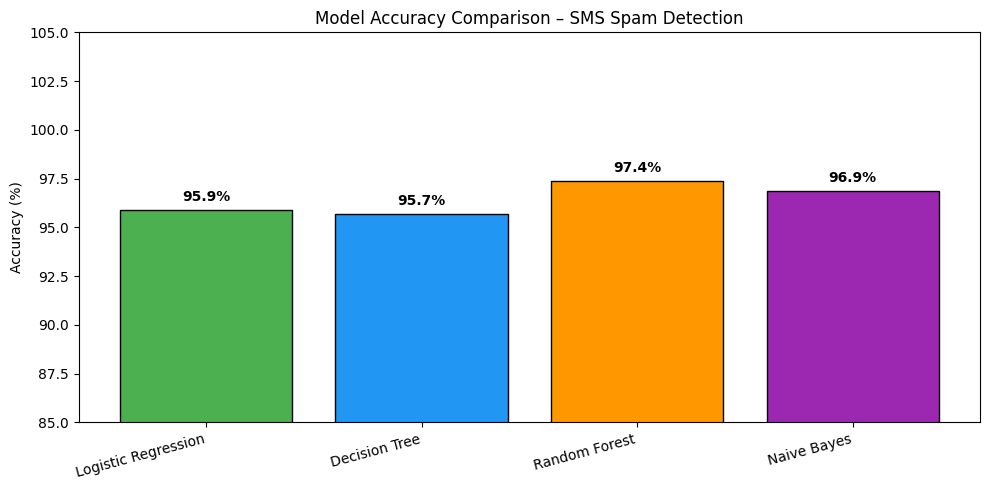

In [12]:
plt.figure(figsize=(10, 5))
bars = plt.bar(
    results.keys(),
    [v * 100 for v in results.values()],
    color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'],
    edgecolor='black'
)
plt.ylim(85, 105)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison – SMS Spam Detection')
plt.xticks(rotation=15, ha='right')

for bar, val in zip(bars, results.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val*100:.1f}%',
        ha='center', va='bottom', fontweight='bold'
    )

plt.tight_layout()
plt.show()

## Step 8 — Confusion Matrix (Best Model)

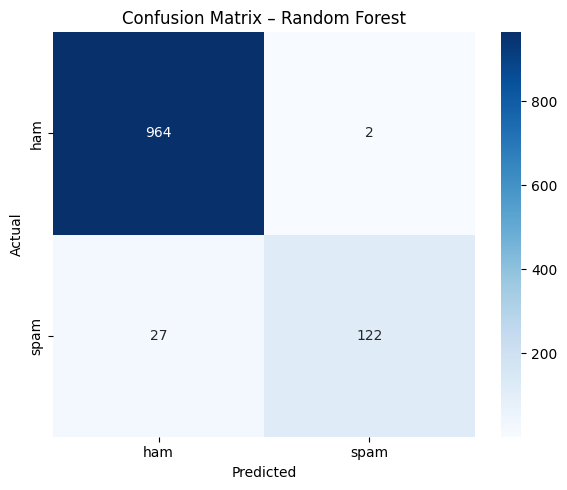


🏆 Best Model: Random Forest
   Accuracy  : 97.40%


In [13]:
best_name  = max(results, key=results.get)
best_model = models[best_name]
best_preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title(f'Confusion Matrix – {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f'\n🏆 Best Model: {best_name}')
print(f'   Accuracy  : {results[best_name]*100:.2f}%')

## Step 9 — Predict a New Message

In [14]:
# Change this message to test your own inputs
sample_messages = [
    "Congratulations! You've won a FREE iPhone. Click here to claim now!",
    "Hey, are we still on for dinner tonight?",
    "URGENT: Your account has been compromised. Send your password immediately.",
    "Just checking in, hope you're doing well!"
]

print('🔮 Prediction Demo')
print('=' * 55)

for msg in sample_messages:
    cleaned = clean_text(msg)
    vectorized = tfidf.transform([cleaned])
    prediction = best_model.predict(vectorized)
    label = le.inverse_transform(prediction)[0]
    emoji = '🚫 SPAM' if label == 'spam' else '✅ HAM'
    print(f'Message : "{msg[:60]}..."' if len(msg) > 60 else f'Message : "{msg}"')
    print(f'Result  : {emoji}')
    print('-' * 55)

🔮 Prediction Demo
Message : "Congratulations! You've won a FREE iPhone. Click here to cla..."
Result  : 🚫 SPAM
-------------------------------------------------------
Message : "Hey, are we still on for dinner tonight?"
Result  : ✅ HAM
-------------------------------------------------------
Message : "URGENT: Your account has been compromised. Send your passwor..."
Result  : 🚫 SPAM
-------------------------------------------------------
Message : "Just checking in, hope you're doing well!"
Result  : ✅ HAM
-------------------------------------------------------


## Step 10 — Final Summary

In [15]:
print('=' * 55)
print('               FINAL RESULTS SUMMARY')
print('=' * 55)
for name, acc in results.items():
    marker = '✅ BEST' if name == best_name else '      '
    print(f'  {marker}  {name:<35} {acc*100:.2f}%')
print('=' * 55)

               FINAL RESULTS SUMMARY
          Logistic Regression                 95.87%
          Decision Tree                       95.70%
  ✅ BEST  Random Forest                       97.40%
          Naive Bayes                         96.86%
